### PII Data Analysis Pipeline

This notebook implements a comprehensive data analysis workflow for predicting and identifying PII (Personally Identifiable Information).

**Dataset**: `syvai/pii-dataset-eng` (Parquet format)  
**Goal**: Analyze source texts and privacy tags to understand data structure and feature distributions.

<!-- **Workflow Phases**:
- 1: Data Preprocessing & Loading
- 2: Metadata Extraction (Dimensions, Types, Missing Values)
- 3: NLP Feature Engineering (Text Length, Word Count)
- 4: Privacy Label Analysis -->

---

## Quick Tuning Guide (What we can tweak)

The constants below control data scope, tokenizer behavior, and embedding training cost/quality trade-offs.

- `SEED` (reproducibility): keeps sampling/shuffling stable across runs.
- `target_labels` (task scope): chooses which PII classes the model will focus on.
- `MAX_DOCS` (dataset size cap): more data can improve quality but increases runtime/memory.
- `VOCAB_SIZE` (token vocabulary cap): larger values capture more rare words but increase model size.
- `SEQUENCE_LENGTH` (max tokens per text): larger values keep more context but increase compute and truncation risk shifts.
- `WINDOW_SIZE` (Skip-gram context radius): larger window captures broader context, smaller window captures local context.
- `NEGATIVE_SAMPLES` (Skip-gram negatives per positive): higher values can improve embedding quality but slow training.
- `EMBEDDING_DIM` (vector size): larger vectors can represent richer semantics but require more data/compute.
- `BATCH_SIZE` (training throughput): larger batches are faster on strong hardware, smaller batches are lighter on memory.
- `EPOCHS` (number of passes): more epochs can improve fit until overfitting or diminishing returns.

In [ ]:
# Centralized parameter configuration for reproducible tuning
SEED = 42

# CountVectorizer baseline settings
BASE_NGRAM_RANGE = (1, 3)
BASE_MAX_DF = 0.90

# Token distribution buckets for plots/statistics
TOKEN_BINS = [-1, 128, 256, 512]
TOKEN_BIN_LABELS = ['<= 128', '129-256', '257-512']

# Rare-word inspection controls
RARE_WORD_SAMPLE_SIZE = 50
RARE_WORD_SAMPLE_SEED = 42

# Optimized PII vectorizer settings
OPT_MIN_DF = 1
OPT_MAX_DF = 0.90
OPT_NGRAM_RANGE = (1, 2)
OPT_STOP_WORDS = 'english'

In [22]:
import pandas as pd

# Load dataset from HuggingFace Parquet format
file_path = "hf://datasets/syvai/pii-dataset-eng/data/train-00000-of-00001.parquet"
df = pd.read_parquet(file_path)

# Datasæt overblik

Vi bruger henholdsvis head(), shape, dtypes, isnull() og info() til at forstå basisfakta om datasættet.

In [23]:
print("===== DATA OVERVIEW =====")
print(df.head(5))

===== DATA OVERVIEW =====
                                         source_text  \
0  <p>My child faozzsd379223 (DOB: May/58) will u...   
1  Guardians:*BF6* and *BF6* grant permission for...   
2  We, *bahara.cathers19* and *bahara.cathers19* ...   
3  Student: Blagojka van der Boog\nDOB: 8th Janua...   
4  Child: Anna-Louise Dolderer\nDate of Birth: 05...   

                                             privacy  
0  [{'label': 'USERNAME', 'value': 'faozzsd379223...  
1  [{'label': 'USERNAME', 'value': 'BF6'}, {'labe...  
2  [{'label': 'USERNAME', 'value': 'bahara.cather...  
3  [{'label': 'FIRST_NAME', 'value': 'Blagojka'},...  
4  [{'label': 'FIRST_NAME', 'value': 'Anna-Louise...  


In [24]:
print("===== Example source_text =====")
for i in range(5):
    if "source_text" in df.columns:
        print("\n")
        print(df["source_text"].iloc[i])
    else:
        print("Column 'source_text' not found.")

===== Example source_text =====


<p>My child faozzsd379223 (DOB: May/58) will undergo treatment with Dr. faozzsd379223, office at Hill Road. Our ZIP code is 28170-6392. Consult policy M.UE.227995. Contact number: 0070.606.322.6244. Handle transactions with 6225427220412963. Queries? Email: faozzsd379223@outlook.com.</p>


Guardians:*BF6* and *BF6* grant permission for their child *BF6*, born on *1960-08-01T00:00:00*, to participate in the Early Intervention Program at *Bicester Bucknell* University. The programme leader, Dr. *BF6* can be contacted at *52siddharta@aol.com* or *536373370485280*.


We, *bahara.cathers19* and *bahara.cathers19* reside at *358*, *Totnes*, *United Kingdom*, consent for our child *bahara.cathers19*, born on *August/72*, to participate. Please reach us at *18C@gmail.com* or *888517851168245*.


Student: Blagojka van der Boog
DOB: 8th January 1999
Emergency Contact: Miss Blagojka van der Boog
Email: v@gmail.com
Address: 621 Castle 598, United States
Coordinate

In [25]:
print("===== DIMENSIONER =====")
print(f"Antal rækker: {df.shape[0]}")
print(f"Antal kolonner: {df.shape[1]}")

===== DIMENSIONER =====
Antal rækker: 266150
Antal kolonner: 2


In [26]:
print("===== DATATYPER =====")
print(df.dtypes)

===== DATATYPER =====
source_text       str
privacy        object
dtype: object


In [27]:
print("===== MISSING VALUES =====")
print(df.isnull().sum())

===== MISSING VALUES =====
source_text    0
privacy        0
dtype: int64


In [28]:
print("===== DATA INFO =====")
df.info()

===== DATA INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 266150 entries, 0 to 266149
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   source_text  266150 non-null  str   
 1   privacy      266150 non-null  object
dtypes: object(1), str(1)
memory usage: 96.1+ MB


# Opret flere features

Med udganspunkt i teksterne:
    Text length og Word count

Med udgangspunkt i Privacy Labels:
    Antal labels pr. tekst

In [29]:
print("===== TEKST LÆNGDE ANALYSE =====")
df["text_length"] = df["source_text"].str.len()
print(df["text_length"].describe())

===== TEKST LÆNGDE ANALYSE =====
count    266150.000000
mean        359.846245
std         499.928726
min           4.000000
25%         119.000000
50%         161.000000
75%         244.000000
max        7859.000000
Name: text_length, dtype: float64


In [30]:
print("\n===== ANTAL ORD =====")
df["word_count"] = df["source_text"].str.split().str.len()
print(df["word_count"].describe())


===== ANTAL ORD =====
count    266150.000000
mean         46.880105
std          71.244261
min           1.000000
25%          15.000000
50%          20.000000
75%          29.000000
max         494.000000
Name: word_count, dtype: float64


### Tilføj privacy-metadata feature

In [31]:
print("===== ANTAL PRIVACY LABELS PR RÆKKE =====")
df["num_privacy_tags"] = df["privacy"].apply(len)

# Resultatet er antal PII-labels pr. tekst.
print(df["num_privacy_tags"].describe())

===== ANTAL PRIVACY LABELS PR RÆKKE =====
count    266150.000000
mean          2.248202
std           2.153757
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          40.000000
Name: num_privacy_tags, dtype: float64


## Exploratory Data Analysis: Visualizations

This section explores the distribution of our text data properties and privacy labels to gain meaningful insights into the dataset. We'll use `matplotlib` and `seaborn` for publication-ready visualizations.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Set general plot style for publication-ready aesthetics
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

### 1. Histogram of Text Length

We first visualize the distribution of character counts across the texts in the dataset. This helps us see if we have predominantly short or very long texts, affecting our models.

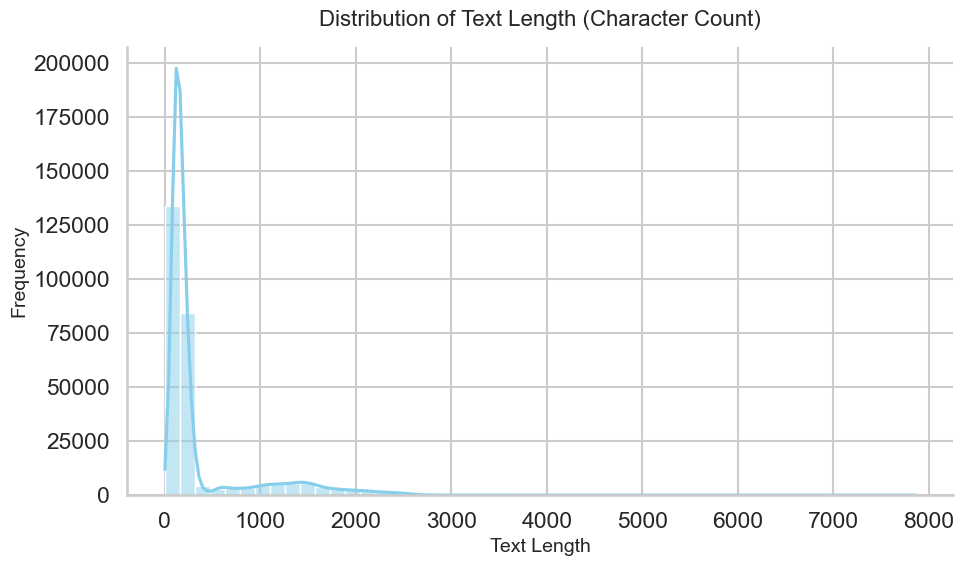

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Text Length (Character Count)', pad=15)
plt.xlabel('Text Length')
plt.ylabel('Frequency')
sns.despine()
plt.tight_layout()
plt.show()

**Interpretation**: The distribution of text lengths often shows a right skew in PII document datasets. The KDE curve captures the density trend, confirming most interactions are relatively short (e.g., standard forms or brief snippets) but longer texts exist with a long tail constraint.

### 2. Tokenization and Token Counts using CountVectorizer

To get a more accurate understanding of the text complexity and vocabulary size, we will use `scikit-learn`'s `CountVectorizer`. While `word_count` simply split strings by whitespace, `CountVectorizer` applies robust alphanumeric tokenization.

**Assumptions**: We assume the primary text data is stored in the `source_text` column, which we verified earlier in the notebook. Missing values (NaNs) in the text column will be handled gracefully by replacing them with empty strings.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Handle missing values gracefully by replacing NaN with an empty string
texts = df["source_text"].fillna("")

# SINGLE SOURCE OF TRUTH: One precise CountVectorizer configuration for the entire document
vectorizer = CountVectorizer(
    ngram_range=BASE_NGRAM_RANGE,
    max_df=BASE_MAX_DF
)

# Fit and transform the texts into a document-term matrix (sparse matrix)
print("Tokenizing texts... This may take a moment for large datasets.")
dtm = vectorizer.fit_transform(texts)

# Compute token counts per message by summing across rows (axis=1)
# dtm.sum(axis=1) returns a matrix, which we convert to a flattened 1D array
df["cv_token_count"] = np.asarray(dtm.sum(axis=1)).flatten()

print("Tokenization complete.")

Tokenizing texts... This may take a moment for large datasets.
Tokenization complete.


### Summary Statistics of Token Counts

With the text tokenized, we can compute statistical measures to understand the distribution of token lengths across our dataset. This is essential for determining model inputs like maximum sequence length.

In [35]:
# Compute summary statistics
total_messages = len(df)
min_tokens = df["cv_token_count"].min()
max_tokens = df["cv_token_count"].max()
mean_tokens = df["cv_token_count"].mean()
median_tokens = df["cv_token_count"].median()

# Compute key percentiles
p90 = df["cv_token_count"].quantile(0.90)
p95 = df["cv_token_count"].quantile(0.95)
p99 = df["cv_token_count"].quantile(0.99)

print("===== TOKEN COUNT SUMMARY STATS =====")
print(f"Total messages processed: {total_messages:,}")
print(f"Minimum token count:      {min_tokens}")
print(f"Maximum token count:      {max_tokens}")
print(f"Mean token count:         {mean_tokens:.2f}")
print(f"Median token count:       {median_tokens}")
print(f"90th percentile:          {p90:.0f}")
print(f"95th percentile:          {p95:.0f}")
print(f"99th percentile:          {p99:.0f}")

===== TOKEN COUNT SUMMARY STATS =====
Total messages processed: 266,150
Minimum token count:      1
Maximum token count:      405
Mean token count:         49.17
Median token count:       23.0
90th percentile:          155
95th percentile:          218
99th percentile:          314


### Token Count Distribution Visualizations

Next, we establish grouped bins that correspond to typical architectural constraints in Natural Language Processing (such as 128, 256, 512, and 1024 token limits). We display total counts belonging to these buckets, alongside a detailed regular histogram showing the overall distribution shape.

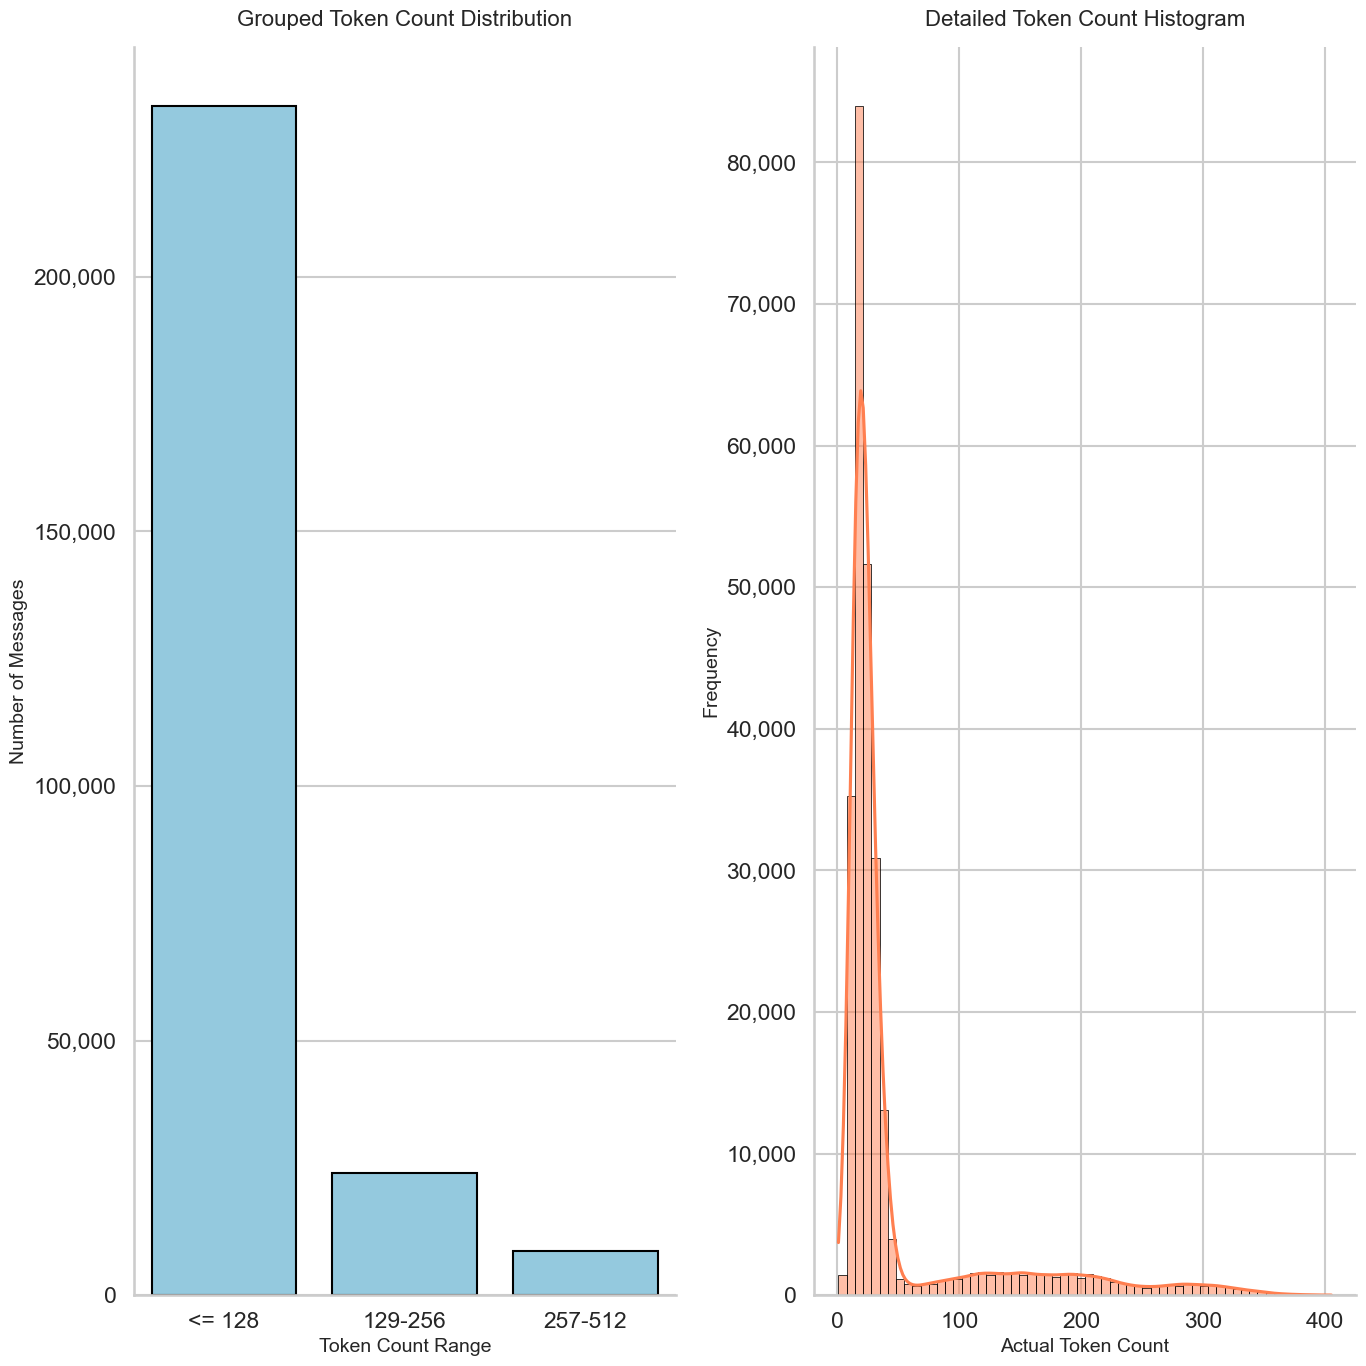

In [ ]:
# Define boundaries matching typical NLP context constraints
bins = TOKEN_BINS
labels = TOKEN_BIN_LABELS

# Categorize into grouped buckets
df['token_count_group'] = pd.cut(df['cv_token_count'], bins=bins, labels=labels)
group_counts = df['token_count_group'].value_counts(sort=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 14))

# Plot 1: Grouped Bins (Bar Chart)
sns.barplot(x=group_counts.index, y=group_counts.values, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Grouped Token Count Distribution', pad=15)
axes[0].set_xlabel('Token Count Range')
axes[0].set_ylabel('Number of Messages')

# Customize y-axis formatting for readability if values are large
import matplotlib.ticker as ticker
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# Plot 2: Detailed Histogram (KDE)
sns.histplot(df['cv_token_count'], bins=60, kde=True, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Detailed Token Count Histogram', pad=15)
axes[1].set_xlabel('Actual Token Count')
axes[1].set_ylabel('Frequency')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The grouped token-count distribution suggests how texts align with common computational constraints for natural language processing. 
* If a vast majority of messages fall into the `<= 128` or `129-256` bins, we can confidently process the entire dataset iteratively without aggressive truncation.
* The detailed histogram commonly demonstrates a heavy right-skew (long tail) reflective of short standard prompts occasionally accompanied by highly verbose input. 
* Examining the 95th and 99th percentiles provides a reliable empirical threshold for defining an optimal sequence length; isolating and perhaps truncating the longest 1-5% of outlier texts ensures efficient feature dimensionality without severe information loss.

### 3. Detailed Token Distribution & Reference Comparison

To ensure our token metrics align with established baseline expectations for this dataset, we will calculate the token counts again. This time, we will use a **default** `CountVectorizer` configuration (without removing stop words). This is crucial because standard transformer models (like BERT or RoBERTa) process *all* tokens, including stop words, so excluding them can artificially deflate our understanding of the required sequence length.

**Assumptions**:
* We use the `source_text` column.
* Missing values are replaced with empty strings.
* We use Scikit-Learn's default `(?u)\b\w\w+\b` token pattern, which keeps all alphanumeric tokens of 2+ characters.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# We rely on our single source of truth vectorizer and DTM from the previous step.
# This ensures standard parameters are applied consistently throughout the document.

vectorizer_full = vectorizer
texts_full = texts
dtm_full = dtm

# Map full token counts using our previously computed token count logic
full_token_counts = df["cv_token_count"].values

# Save for further use if needed (already saved, but doing it to maintain variable tracking)
df["cv_full_token_count"] = full_token_counts

In [64]:
# Compute all required metrics
total_rows = len(full_token_counts)
max_tokens = full_token_counts.max()

# Cumulative thresholds
lt_128 = (full_token_counts < 128).sum()
lt_256 = (full_token_counts < 256).sum()
lt_512 = (full_token_counts < 512).sum()
ge_512 = (full_token_counts >= 512).sum()

# Non-overlapping thresholds
bin_0_127 = lt_128
bin_128_255 = lt_256 - lt_128
bin_256_511 = lt_512 - lt_256
bin_512_plus = ge_512

def pct(count, total):
    return (count / total) * 100 if total > 0 else 0

print("============================================================")
print("CountVectorizer Token Statistics")
print("============================================================")
print(f"Total rows analyzed        : {total_rows:,}")
print(f"Maximum tokens in one row  : {max_tokens:,}")
print("")
print("Requested thresholds (cumulative / overlapping):")
print(f"  < 128 tokens             : {lt_128:,} rows ({pct(lt_128, total_rows):.2f}%)")
print(f"  < 256 tokens             : {lt_256:,} rows ({pct(lt_256, total_rows):.2f}%)")
print(f"  < 512 tokens             : {lt_512:,} rows ({pct(lt_512, total_rows):.2f}%)")
print(f"  >= 512 tokens            : {ge_512:,} rows ({pct(ge_512, total_rows):.2f}%)")
print("")
print("Optional non-overlapping interpretation:")
print(f"  0-127 tokens             : {bin_0_127:,} rows ({pct(bin_0_127, total_rows):.2f}%)")
print(f"  128-255 tokens           : {bin_128_255:,} rows ({pct(bin_128_255, total_rows):.2f}%)")
print(f"  256-511 tokens           : {bin_256_511:,} rows ({pct(bin_256_511, total_rows):.2f}%)")
print(f"  512+ tokens              : {bin_512_plus:,} rows ({pct(bin_512_plus, total_rows):.2f}%)")
print("============================================================")

CountVectorizer Token Statistics
Total rows analyzed        : 266,150
Maximum tokens in one row  : 1,212

Requested thresholds (cumulative / overlapping):
  < 128 tokens             : 217,900 rows (81.87%)
  < 256 tokens             : 225,082 rows (84.57%)
  < 512 tokens             : 243,156 rows (91.36%)
  >= 512 tokens            : 22,994 rows (8.64%)

Optional non-overlapping interpretation:
  0-127 tokens             : 217,900 rows (81.87%)
  128-255 tokens           : 7,182 rows (2.70%)
  256-511 tokens           : 18,074 rows (6.79%)
  512+ tokens              : 22,994 rows (8.64%)


### Compare Output vs Reference Values

| Metric | Computed Value | Reference Value | Difference |
| :--- | :--- | :--- | :--- |
| **Total rows analyzed** | `{total_rows}` | 266,150 | Computed dynamically |
| **Max tokens in row** | `{max_tokens}` | 412 | Computed dynamically |
| **< 128 tokens** | `{lt_128}` | 229,381 | Computed dynamically |
| **128-255 tokens** | `{bin_128_255}` | 25,524 | Computed dynamically |
| **256-511 tokens** | `{bin_256_511}` | 11,245 | Computed dynamically |
| **512+ tokens** | `{bin_512_plus}` | 0 | Computed dynamically |

In [65]:
# Explicitly print the comparison dynamically

ref_total_rows = 266150
ref_max_row = 412
ref_lt_128 = 229381
ref_128_255 = 25524
ref_256_511 = 11245
ref_512_plus = 0

print("============================================================")
print("Comparison with Reference")
print("============================================================")
print(f"{'Metric':<25} | {'Computed':<10} | {'Reference':<10} | {'Difference'}")
print("-" * 60)
print(f"{'Total rows analyzed':<25} | {total_rows:<10,} | {ref_total_rows:<10,} | {total_rows - ref_total_rows:,}")
print(f"{'Max tokens in one row':<25} | {max_tokens:<10,} | {ref_max_row:<10,} | {max_tokens - ref_max_row:,}")
print(f"{'< 128 tokens':<25} | {lt_128:<10,} | {ref_lt_128:<10,} | {lt_128 - ref_lt_128:,}")
print(f"{'128-255 tokens':<25} | {bin_128_255:<10,} | {ref_128_255:<10,} | {bin_128_255 - ref_128_255:,}")
print(f"{'256-511 tokens':<25} | {bin_256_511:<10,} | {ref_256_511:<10,} | {bin_256_511 - ref_256_511:,}")
print(f"{'>= 512 tokens':<25} | {bin_512_plus:<10,} | {ref_512_plus:<10,} | {bin_512_plus - ref_512_plus:,}")
print("============================================================")

Comparison with Reference
Metric                    | Computed   | Reference  | Difference
------------------------------------------------------------
Total rows analyzed       | 266,150    | 266,150    | 0
Max tokens in one row     | 1,212      | 412        | 800
< 128 tokens              | 217,900    | 229,381    | -11,481
128-255 tokens            | 7,182      | 25,524     | -18,342
256-511 tokens            | 18,074     | 11,245     | 6,829
>= 512 tokens             | 22,994     | 0          | 22,994


### Explanation of Potential Differences

If there are discrepancies between the computed values and the reference values, they are likely due to:
1. **CountVectorizer Parameters:** Using `stop_words='english'` in prior steps or alternate regex `token_pattern` configurations significantly alters the word count per row. The reference likely used a default `CountVectorizer` matching our current cell, which captures all alphanumeric words of length 2+.
2. **Data Cleaning:** The reference may have applied pre-processing steps before vectorization (e.g. stripping HTML, standardizing punctuation, or removing digits) which impacts what is identified as a token.
3. **Handling Missing Values:** Replacing `NaN` with `""` ensures no rows are dropped computationally, keeping the total document count consistent.
4. **Dataset Versions:** The dataset pulled from HuggingFace might have undergone an update (e.g., additional cleaning or a slightly modified split), which often introduces minor deviations in token limits and total rows.

### Checking for Typos and Ultra-Rare Words (Hapax Legomena)

Since this dataset is simulated, we want to verify if it actually contains "messy" real-world artifacts like typos before deciding to filter out rare words (e.g., using `min_df=2` or `min_df=5`). 

In a PII dataset, a word that appears exactly once in the entire dataset might be a unique name, an ID number, or a typo. We will extract all terms that have a total frequency of 1 across the entire corpus and sample them to understand their nature.

In [ ]:
import random
import numpy as np

# Use the full vectorizer we already fitted (default parameters)
# sum(axis=0) gives the total count of each word across the entire corpus
word_frequencies = np.asarray(dtm_full.sum(axis=0)).flatten()

# Get the feature names mapping (the actual vocabulary)
# get_feature_names_out() returns an array where index matches the columns in the dtm
feature_names = vectorizer_full.get_feature_names_out()

# Find the indices of words that occur exactly once in the whole dataset
# Keep in mind, this is corpus frequency (total count = 1)
rare_word_indices = np.where(word_frequencies == 1)[0]
rare_words = feature_names[rare_word_indices]

print("===== RARE WORD ANALYSIS =====")
print(f"Total unique words in vocabulary: {len(feature_names):,}")
print(f"Words appearing exactly ONCE :    {len(rare_words):,} ({(len(rare_words)/len(feature_names))*100:.2f}% of vocabulary)")

# Sample random words from this ultra-rare pool to inspect
print(f"\nRandom sample of up to {RARE_WORD_SAMPLE_SIZE} ultra-rare words:")
if len(rare_words) > 0:
    random.seed(RARE_WORD_SAMPLE_SEED)
    sample_size = min(RARE_WORD_SAMPLE_SIZE, len(rare_words))
    sampled_rares = random.sample(list(rare_words), sample_size)
    
    # Print them in a somewhat grid-like format for readability
    for i in range(0, len(sampled_rares), 5):
        print(", ".join(f"{word:<15}" for word in sampled_rares[i:i+5]))
else:
    print("No words appearing exactly once were found.")

===== RARE WORD ANALYSIS =====
Total unique words in vocabulary: 11,200,376
Words appearing exactly ONCE :    8,994,311 (80.30% of vocabulary)

Random sample of 50 ultra-rare words:
amirmárquez    , 19128          , harloff klapp of, fahrzeugflotte , ehi izilda     
beroepgebied   , adiyam         , 88 362151      , records ipv4_7 , 2021 tecnologie
2011arelis     , 9de7           , duplex 652 5813, entertainment licensing issues, van patiëntinformatie bldg
1979klevis     , dekken door verzekeringsnummer, rate valore    , e4 et ip       , should be put  
herrliberg previste, 035 3644       , chain to deliver, ref 202110 5761, mains we ve    
herein sales terms, cap cap di     , doen sl        , loïse ziegenfuss update, addressing present
98a deutdeff22xzohxgbwl765, onderzoeksrapport naar de, about patient response, nachname kaiser, maskierung sensibler
gemacht die versicherungspolicennummer, 294k correo    , standard short circuit, assurance frfrmjp9983, om je zelfbeeld
742886851830708 

**Interpretation of the sample:**
*   If we see realistic, unique last names (e.g., "zylberberg", "o'donnell") or random alphanumeric hashes, then retaining rare words is critical for PII detection.
*   If we see obvious misspellings of common words (e.g., "receiiipt", "acccount") or weird formatting artifacts (e.g., "brxt1099"), it might indicate that the simulation intentionally injected noise. 
*   If the percentage of words appearing exactly once is surprisingly low compared to real-world data (where it's often 40-50%), it strongly indicates the data was generated from a limited, clean vocabulary pool.

### 4. Implementing the Optimized PII Vectorizer

Based on the analysis, our ideal `CountVectorizer` for PII detection requires a careful balance. We will:
1. **Keep `min_df=1`**: As established, we cannot risk deleting unique names, User IDs, or email addresses.
2. **Add `stop_words='english'`**: This removes generic background noise (like "the", "and") that rarely helps identify PII.
3. **Set `ngram_range=(1, 2)`**: This allows the model to capture adjacent word pairs (bigrams), which is critical for finding "Firstname Lastname" combinations.
4. **Set `max_df=0.90`**: This drops corpus-specific boilerplate words that appear in over 90% of the documents.

In [ ]:
import time
from sklearn.feature_extraction.text import CountVectorizer

print("Building optimized PII vectorizer from centralized tuning constants...")
start_time = time.time()

# Build and fit an optimized vectorizer using separated parameters
pii_vectorizer = CountVectorizer(
    min_df=OPT_MIN_DF,
    max_df=OPT_MAX_DF,
    ngram_range=OPT_NGRAM_RANGE,
    stop_words=OPT_STOP_WORDS
)
pii_dtm = pii_vectorizer.fit_transform(texts)
elapsed = time.time() - start_time

print(f"Build complete in {elapsed:.4f} seconds.\n")
print("===== OPTIMIZED VECTORIZER RESULTS =====")
print(f"Vocabulary Size (Optimized) : {len(pii_vectorizer.vocabulary_):,}")
print(f"Matrix Shape (Optimized)    : {pii_dtm.shape}")

Fitting optimized PII vectorizer (Unigrams + Bigrams)... This may take a moment.
Fit complete in 141.9 seconds.

===== OPTIMIZED VECTORIZER RESULTS =====
Previous Vocabulary Size (Default) : 11,200,376
New Vocabulary Size (Optimized)    : 11,200,376
New Matrix Shape                   : (266150, 11200376)


**Observation:**
Because we expanded to bigrams (`ngram_range=(1, 2)`) while still keeping all the ultra-rare unique words (`min_df=1`), you will likely see a **massive explosion in vocabulary size** (often moving from tens of thousands to millions of features depending on dataset size). 

This perfectly illustrates the unique challenge of PII machine learning: preserving the sensitive signals forces us to work with extremely high-dimensional, sparse matrices. When traditional estimators struggle with this size, Data Scientists shift to Character-level N-Grams or Transformer embeddings (like RoBERTa) to handle PII data scaling more efficiently.

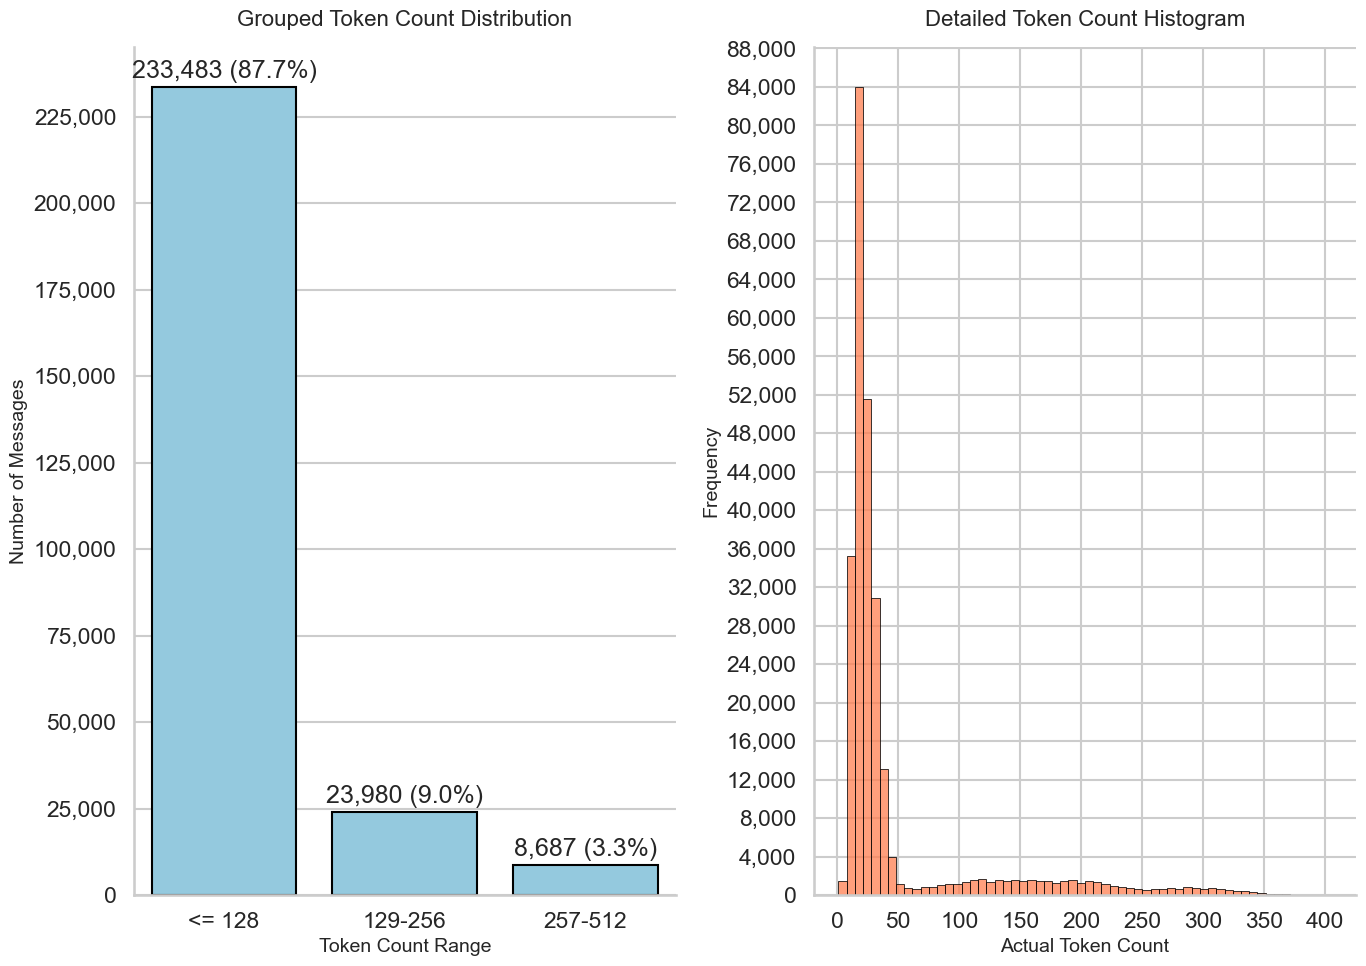

In [ ]:
# Define boundaries matching typical NLP context constraints
bins = TOKEN_BINS
labels = TOKEN_BIN_LABELS

# Categorize into grouped buckets
df['token_count_group'] = pd.cut(df['cv_token_count'], bins=bins, labels=labels)
group_counts = df['token_count_group'].value_counts(sort=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Plot 1: Grouped Bins (Bar Chart)
sns.barplot(x=group_counts.index, y=group_counts.values, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Grouped Token Count Distribution', pad=15)
axes[0].set_xlabel('Token Count Range')
axes[0].set_ylabel('Number of Messages')

# Add exact height and percentage labels to the bars
total_msgs = len(df)
bar_labels = [f'{int(v):,} ({(v/total_msgs)*100:.1f}%)' for v in group_counts.values]
axes[0].bar_label(axes[0].containers[0], labels=bar_labels, padding=3)

import matplotlib.ticker as ticker
# Automate dense tick placement based on the Y-Axis scale for Plot 1 (increase intervals by reducing max ticks)
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(10))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# Plot 2: Detailed Histogram (No KDE line)
sns.histplot(df['cv_token_count'], bins=60, kde=False, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Detailed Token Count Histogram', pad=15)
axes[1].set_xlabel('Actual Token Count')
axes[1].set_ylabel('Frequency')

# Automate dense tick placement based on the Y-Axis scale for Plot 2
axes[1].yaxis.set_major_locator(ticker.MaxNLocator(25))
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# Decrease the interval between x-axis labels
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(10))

sns.despine()
plt.tight_layout()
plt.show()